In [ ]:
import glob
from PIL import Image
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import os

IMG_SIZE = (224, 224)

model = load_model('models/stage2_dino_species.keras')

with open("models/stage2_dino_classes.json", "r") as f:
    class_names = json.load(f)

print(list(class_names.items()))

[('0', 'Allosaurus'), ('1', 'Ankylosaurus'), ('2', 'Apatosaurus'), ('3', 'Archaeopteryx'), ('4', 'Argentinosaurus'), ('5', 'Atrociraptor'), ('6', 'Barosaurus'), ('7', 'Baryonyx'), ('8', 'Brachiosaurus'), ('9', 'Brontosaurus'), ('10', 'Carnotaurus'), ('11', 'Ceratosaurus'), ('12', 'Compsognathus'), ('13', 'Corythosaurus'), ('14', 'Dilophosaurus'), ('15', 'Dimetrodon'), ('16', 'Dimorphodon'), ('17', 'Diplodocus'), ('18', 'Europasaurus'), ('19', 'Gallimimus'), ('20', 'Giganotosaurus'), ('21', 'Iguanodon'), ('22', 'Lystrosaurus'), ('23', 'Maiasaura'), ('24', 'Mamenchisaurus'), ('25', 'Microceratus'), ('26', 'Mosasaurus'), ('27', 'Nasutoceratops'), ('28', 'Nodosaurus'), ('29', 'Oviraptor'), ('30', 'Pachycephalosaurus'), ('31', 'Parasaurolophus'), ('32', 'Pteranodon'), ('33', 'Pterodactyl'), ('34', 'Pyroraptor'), ('35', 'Quetzalcoatlus'), ('36', 'Sinoceratops'), ('37', 'Spinosaurus'), ('38', 'Stegosaurus'), ('39', 'Stygimoloch'), ('40', 'Styracosaurus'), ('41', 'Therizinosaurus'), ('42', 'Tr

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


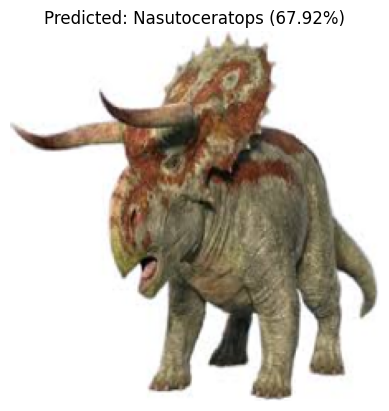

Top 3 передбачення:
1. Nasutoceratops — 67.92%
2. Triceratops — 14.17%
3. Styracosaurus — 10.00%


In [22]:
from tensorflow.keras.applications.resnet50 import preprocess_input

img_path = "dataset/test_class_dino/nasut1.jpg" 
img = Image.open(img_path).convert("RGB")
img = img.resize(IMG_SIZE)
img_array = np.array(img)

img_array = np.expand_dims(img_array, axis=0) 
img_array = preprocess_input(img_array)

preds = model.predict(img_array)[0]

top3_idx = preds.argsort()[-3:][::-1]   
top3_probs = preds[top3_idx]            
top3_classes = [class_names[str(i)] for i in top3_idx]

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {top3_classes[0]} ({top3_probs[0]*100:.2f}%)")
plt.show()

print("Top 3 передбачення:")
for i in range(3):
    print(f"{i+1}. {top3_classes[i]} — {top3_probs[i]*100:.2f}%")